# Common Libraries

In [26]:
import os, sys, shutil, mediapy
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pylab as plt
import xml.etree.ElementTree as ET

if shutil.which("nvidia-smi") is not None:
    os.environ["MUJOCO_GL"] = "egl"
import mujoco

# Params

In [29]:
model_path = "/mnt/sdb2/DeepProprioception/Projects/DP01_mri/Myosuite/Model/scaled_model_cvt3_mocap.xml"

# Initialize model

In [35]:
model = mujoco.MjModel.from_xml_path(model_path)

# Model constants
joint_names = [mujoco.mj_id2name(model, mujoco.mjtObj.mjOBJ_JOINT, idx) for idx in range(model.njnt)]
n_joint = len(joint_names)

# Joint indexing
interest_joint_names = ["elv_angle", "shoulder_elv", "elbow_flexion"]
goal_angle_map = {}
goal_angle_map["elv_angle"] = 2.27
goal_angle_map["shoulder_elv"] = 1.6
goal_angle_map["elbow_flexion"] = 0

interest_joint_map = {}
for joint_name in interest_joint_names:
    jnt_id = model.joint(joint_name).id
    qpos_idx = model.jnt_qposadr[jnt_id]
    dof_idx = model.jnt_dofadr[jnt_id]
    
    interest_joint_map[joint_name] = {
        "joint_id" : jnt_id,
        "qposadr" : qpos_idx,
        "dofadr" : dof_idx,
        "goal_angle" : goal_angle_map[joint_name],
    }

# Initialize pose
mj_data = mujoco.MjData(model)
mujoco.mj_forward(model, mj_data)

# Renderer

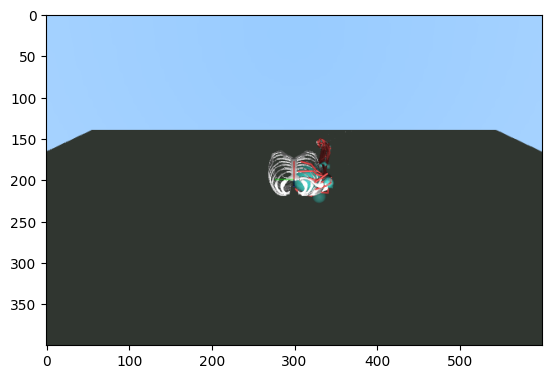

In [36]:
# Renderer
renderer = mujoco.Renderer(model, height=400, width=600)
scene_option = mujoco.MjvOption()
scene_option.frame = mujoco.mjtFrame.mjFRAME_WORLD

# Camera
camera = mujoco.MjvCamera()
camera.azimuth = 0
camera.elevation = -110
camera.distance = 2.0

# Initial render
renderer.update_scene(mj_data, camera=camera, scene_option=scene_option)
plt.imshow(renderer.render())

# Simulation

if model.opt.timestep is big, the simulation not works well. In this case, model.opt.timestep needs to be set as 0.001
```python
goal_angle_map["elv_angle"] = 2.27
goal_angle_map["shoulder_elv"] = 1.6
goal_angle_map["elbow_flexion"] = 0
```

In [37]:
model.opt.timestep = 0.001

In [38]:
# Initialize start pose
mj_data = mujoco.MjData(model)
mujoco.mj_forward(model, mj_data)

# Goal
final_goal_qpos = mj_data.qpos.copy()
for joint_name in interest_joint_map:
    joint_i = interest_joint_map[joint_name]["joint_id"]
    final_goal_qpos[joint_i] = interest_joint_map[joint_name]["goal_angle"]
    
# Simulation params
n_times = 1000
kp = 500.0  # Stiffness
kv = 50.0   # Damping

# Simulation Constants
times = np.arange(n_times) * model.opt.timestep

# Result dummy
pixels = np.zeros((n_times, renderer.height, renderer.width, 3), dtype = np.uint8)
qpos_traj = pd.DataFrame(np.zeros((n_times, n_joint + 1)))
qpos_traj.columns = ["time"] + joint_names
qforces = pd.DataFrame(np.zeros((n_times, n_joint + 1)))
qforces.columns = ["time"] + joint_names
qerrors = pd.DataFrame(np.zeros((n_times, n_joint + 1)))
qerrors.columns = ["time"] + joint_names

interest_joint_ids = [interest_joint_map[name]["joint_id"] for name in interest_joint_names]
interest_joint_ids = np.array(interest_joint_ids)

# Simulation
for time_i in tqdm(range(n_times)):
    time = times[time_i]
    
    # Current
    current_qpos = mj_data.qpos.copy()
    current_qvel = mj_data.qvel.copy()
    
    # Control
    goal_qpos = mj_data.qpos.copy()
    error_q = np.zeros_like(goal_qpos)
    error_q[interest_joint_ids] = final_goal_qpos[interest_joint_ids] - current_qpos[interest_joint_ids]
    
    error_v = np.zeros_like(goal_qpos)
    error_v[interest_joint_ids] = 0 - current_qvel[interest_joint_ids]
    
    # Force
    tau_all = np.zeros(model.nv)
    tau_all = kp * error_q + kv * error_v
    mj_data.qfrc_applied[:] = tau_all

    # Save
    qpos_traj.iloc[time_i] = np.hstack([time, current_qpos])
    qerrors.iloc[time_i] = np.hstack([time, error_q])
    qforces.iloc[time_i] = np.hstack([time, tau_all])
    
    # Forward dyanmics
    mujoco.mj_step(model, mj_data)   
    
    # Rendering
    renderer.update_scene(mj_data, camera = camera, scene_option = scene_option)
    pixels[time_i] = renderer.render()

100%|██████████| 1000/1000 [00:06<00:00, 150.06it/s]


In [39]:
mediapy.show_video(pixels, fps = 30)

This browser does not support the video tag.


In [17]:
qforces_nonZero = qforces.loc[:, (qforces != 0).any(axis=0)]

In [18]:
qforces_nonZero

,time,elv_angle,shoulder_elv,elbow_flexion
0,0.000,1135.000000,800.000000,0.000000
1,0.001,1125.652122,789.517659,2.140912
2,0.002,1116.305468,779.777345,2.829688
3,0.003,1106.961635,770.666310,3.623588
4,0.004,1097.620606,762.091598,4.520639
...,...,...,...,...
995,0.995,7.350620,166.171937,1.501922
996,0.996,7.333833,166.002417,1.502179
997,0.997,7.316651,165.833606,1.502506
998,0.998,7.299072,165.665513,1.502916
